# 04. GARCH(1,1) — Проверка устойчивости результатов

## Цель
Проверить, сохраняются ли выводы OLS-регрессий (ноутбук 03) при учёте **кластеризации волатильности** (volatility clustering) — характерной черты финансовых временных рядов.

## Спецификация GARCH(1,1)

**Уравнение среднего** (те же факторы, что в OLS):
$$r_{BTC,t} = \mu + \sum_k \beta_k X_{k,t} + \varepsilon_t$$

**Уравнение дисперсии:**
$$\sigma^2_t = \omega + \alpha \varepsilon^2_{t-1} + \beta \sigma^2_{t-1}$$

где $\alpha + \beta < 1$ — условие ковариационной стационарности. Параметр $\alpha$ отражает реакцию волатильности на шоки, $\beta$ — её персистентность.

## Логика проверки устойчивости
- Если GARCH-оценки коэффициентов **совпадают по знаку и значимости** с OLS — выводы устойчивы
- Если картина меняется — необходимо обсудить причины

**Модели:**
- М1: крипто-факторы в уравнении среднего
- М2: внешние факторы в уравнении среднего  
- М3: все факторы в уравнении среднего
- М4: расширенная спецификация (к М3 добавлены золото, Δ10Y Treasury, global EPU)

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from arch import arch_model
from statsmodels.stats.diagnostic import het_arch
import warnings
warnings.filterwarnings('ignore')

# Загружаем данные
df = pd.read_csv('../data/processed/merged_weekly.csv', index_col='date', parse_dates=True)

p1 = df.loc['2017-01-01':'2019-12-31']
p2 = df.loc['2020-01-01':'2025-03-01']

Y_VAR = 'r_btc'
CRYPTO_VARS   = ['r_btc_lag', 'log_volume_btc', 'google_trends']
EXTERNAL_VARS = ['r_sp500', 'vix', 'r_dxy']
EXTERNAL_VARS_EXT = EXTERNAL_VARS + ['r_gold', 'd_yield_10y', 'epu']
ALL_VARS      = CRYPTO_VARS + EXTERNAL_VARS
ALL_VARS_EXT  = CRYPTO_VARS + EXTERNAL_VARS_EXT

var_labels = {
    'Const':          'Константа',
    'r_btc_lag':      'BTC доходность (лаг)',
    'log_volume_btc': 'Log объём BTC',
    'google_trends':  'Google Trends',
    'r_sp500':        'S&P 500 доходность',
    'vix':            'VIX',
    'r_dxy':          'DXY доходность',
    'r_gold':         'Золото доходность',
    'd_yield_10y':    'Δ доходность 10Y Treasury (п.п.)',
    'epu':            'Global EPU',
    'omega':          'ω (GARCH const)',
    'alpha[1]':       'α (ARCH эффект)',
    'beta[1]':        'β (персистентность)',
}

print('Данные загружены.')
print(f'Полный период: {len(df)} недель | P1: {len(p1)} | P2: {len(p2)}')


Данные загружены.
Полный период: 422 недель | P1: 153 | P2: 269


## 1. Тест на ARCH-эффекты

Перед GARCH проверяем, есть ли в остатках OLS кластеризация волатильности (тест Энгла на ARCH-эффекты).

In [12]:
import statsmodels.api as sm

# OLS остатки для теста
sample = df[ALL_VARS_EXT + [Y_VAR]].dropna()
y_ols = sample[Y_VAR]
X_ols = sm.add_constant(sample[ALL_VARS_EXT])
ols_resid = sm.OLS(y_ols, X_ols).fit().resid

# Тест Энгла на ARCH-эффекты (лаги 1, 4, 8)
print('Тест Энгла на ARCH-эффекты (H0: нет ARCH-эффектов):')
print(f'{"Лаг":<6} {"LM-стат.":<12} {"p-value":<12} {"Вывод"}')
for lag in [1, 4, 8]:
    lm, pval, _, _ = het_arch(ols_resid, nlags=lag)
    conclusion = '→ ARCH-эффекты есть' if pval < 0.05 else '→ нет'
    print(f'{lag:<6} {lm:<12.3f} {pval:<12.4f} {conclusion}')

Тест Энгла на ARCH-эффекты (H0: нет ARCH-эффектов):
Лаг    LM-стат.     p-value      Вывод
1      14.312       0.0002       → ARCH-эффекты есть
4      30.628       0.0000       → ARCH-эффекты есть
8      45.027       0.0000       → ARCH-эффекты есть


## 2. Вспомогательные функции

In [13]:
def run_garch(data, y_var, x_vars):
    """
    GARCH(1,1) с факторами в уравнении среднего.
    Доходности масштабируются на 100 для численной стабильности.
    """
    sample = data[[y_var] + x_vars].dropna()
    y = sample[y_var] * 100          # масштабирование
    X = sample[x_vars]

    am = arch_model(
        y, x=X,
        mean='ARX', lags=0,
        vol='GARCH', p=1, q=1,
        dist='normal'
    )
    res = am.fit(disp='off', options={'maxiter': 500})
    return res


def extract_garch_results(res, model_name=''):
    """
    Извлекает параметры из результатов GARCH.
    Возвращает две таблицы: уравнение среднего и уравнение дисперсии.
    """
    params  = res.params
    bse     = res.std_err
    tvals   = res.tvalues
    pvals   = res.pvalues

    mean_rows, var_rows = [], []
    var_params = {'omega', 'alpha[1]', 'beta[1]'}

    for var in params.index:
        pval  = float(pvals[var])
        stars = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.1 else ''))
        row = {
            'Переменная': var_labels.get(var, var),
            'Коэф.':    round(float(params[var]), 4),
            'Ст. ош.':  round(float(bse[var]),    4),
            't-стат.':  round(float(tvals[var]),   3),
            'p-value':  round(pval,                4),
            'Знач.':    stars,
        }
        if var in var_params:
            var_rows.append(row)
        else:
            mean_rows.append(row)

    df_mean = pd.DataFrame(mean_rows).set_index('Переменная')
    df_var  = pd.DataFrame(var_rows).set_index('Переменная')

    # Персистентность α + β
    alpha = float(params.get('alpha[1]', 0))
    beta  = float(params.get('beta[1]',  0))

    meta = pd.Series({
        'Log-Likelihood': round(res.loglikelihood, 2),
        'AIC':            round(res.aic,           2),
        'BIC':            round(res.bic,           2),
        'α + β':          round(alpha + beta,      4),
        'N':              int(res.nobs),
    }, name=model_name)

    return df_mean, df_var, meta


print('Функции определены.')

Функции определены.


## 3. GARCH(1,1) — Полный период (2017–2025)

In [14]:
print('Обучение моделей (может занять ~20–40 сек)...')

g1 = run_garch(df, Y_VAR, CRYPTO_VARS)
g2 = run_garch(df, Y_VAR, EXTERNAL_VARS)
g3 = run_garch(df, Y_VAR, ALL_VARS)
g4 = run_garch(df, Y_VAR, ALL_VARS_EXT)

print('Готово.')

Обучение моделей (может занять ~20–40 сек)...
Готово.


In [15]:
for res, label in [(g1, 'М1: Крипто-факторы'), (g2, 'М2: Внешние факторы'), (g3, 'М3: Все факторы'), (g4, 'М4: Расширенная')]:
    mean_tbl, var_tbl, meta = extract_garch_results(res, label)
    print(f'\n=== GARCH(1,1) — {label} — Полный период ===')
    print('Уравнение среднего:')
    display(mean_tbl)
    print('Уравнение дисперсии:')
    display(var_tbl)
    print(f'AIC={meta["AIC"]:.2f}  BIC={meta["BIC"]:.2f}  α+β={meta["α + β"]:.4f}  N={meta["N"]}')


=== GARCH(1,1) — М1: Крипто-факторы — Полный период ===
Уравнение среднего:


,Коэф.,Ст. ош.,t-стат.,p-value,Знач.
Переменная,,,,,
Константа,1.7690,3.6437,0.486,0.6273,
BTC доходность (лаг),7.8651,5.4363,1.447,0.1480,
Log объём BTC,-0.1714,0.2266,-0.757,0.4493,
Google Trends,0.0332,0.0282,1.178,0.2388,


Уравнение дисперсии:


,Коэф.,Ст. ош.,t-стат.,p-value,Знач.
Переменная,,,,,
ω (GARCH const),0.0000,1.1311,0.000,1.0000,
α (ARCH эффект),0.0137,0.0320,0.430,0.6674,
β (персистентность),0.9830,0.0428,22.985,0.0000,***


AIC=3113.92  BIC=3142.23  α+β=0.9967  N=422.0

=== GARCH(1,1) — М2: Внешние факторы — Полный период ===
Уравнение среднего:


...

AIC=3096.95  BIC=3137.40  α+β=0.9965  N=422.0

=== GARCH(1,1) — М4: Расширенная — Полный период ===
Уравнение среднего:


,Коэф.,Ст. ош.,t-стат.,p-value,Знач.
Переменная,,,,,
Константа,-0.0156,3.5467,-0.004,0.9965,
BTC доходность (лаг),4.0139,5.5112,0.728,0.4664,
Log объём BTC,-0.0224,0.2304,-0.097,0.9227,
Google Trends,0.0364,0.0278,1.309,0.1906,
S&P 500 доходность,83.5525,23.4932,3.556,0.0004,***
VIX,-0.0458,0.1061,-0.431,0.6661,
DXY доходность,35.0467,64.7319,0.541,0.5882,
Золото доходность,27.7802,30.8585,0.900,0.3680,
Δ доходность 10Y Treasury (п.п.),2.5348,3.5051,0.723,0.4696,


Уравнение дисперсии:


,Коэф.,Ст. ош.,t-стат.,p-value,Знач.
Переменная,,,,,
ω (GARCH const),0.0000,1.2995,0.000,1.0000,
α (ARCH эффект),0.0129,0.0387,0.334,0.7388,
β (персистентность),0.9836,0.0526,18.697,0.0000,***


AIC=3101.29  BIC=3153.88  α+β=0.9965  N=422.0


## 4. GARCH(1,1) — Анализ по подпериодам

In [16]:
for period_name, data in [('2017–2019', p1), ('2020–2025', p2)]:
    print(f'\n')
    print(f'ПОДПЕРИОД: {period_name}')
    print('='*60)
    for x_vars, label in [
        (CRYPTO_VARS,   'М1: Крипто-факторы'),
        (EXTERNAL_VARS, 'М2: Внешние факторы'),
    ]:
        r = run_garch(data, Y_VAR, x_vars)
        mean_tbl, var_tbl, meta = extract_garch_results(r, label)
        print(f'\n--- {label} ---')
        display(mean_tbl)
        print(f'α+β={meta["α + β"]:.4f}  AIC={meta["AIC"]:.2f}  N={meta["N"]}')



ПОДПЕРИОД: 2017–2019

--- М1: Крипто-факторы ---


,Коэф.,Ст. ош.,t-стат.,p-value,Знач.
Переменная,,,,,
Константа,7.2427,10.7591,0.673,0.5008,
BTC доходность (лаг),2.3877,8.2017,0.291,0.7710,
Log объём BTC,-0.4791,0.7366,-0.650,0.5155,
Google Trends,0.0268,0.0700,0.383,0.7014,


α+β=0.8528  AIC=1207.12  N=153.0

--- М2: Внешние факторы ---


,Коэф.,Ст. ош.,t-стат.,p-value,Знач.
Переменная,,,,,
Константа,5.1674,4.0489,1.276,0.2019,
S&P 500 доходность,24.7080,61.3601,0.403,0.6872,
VIX,-0.2969,0.2498,-1.189,0.2346,
DXY доходность,-121.1668,129.2428,-0.938,0.3485,


α+β=0.8578  AIC=1204.66  N=153.0


ПОДПЕРИОД: 2020–2025

--- М1: Крипто-факторы ---


,Коэф.,Ст. ош.,t-стат.,p-value,Знач.
Переменная,,,,,
Константа,0.8540,4.2616,0.200,0.8412,
BTC доходность (лаг),11.4139,6.6136,1.726,0.0844,*
Log объём BTC,-0.1424,0.2566,-0.555,0.5790,
Google Trends,0.0400,0.0343,1.166,0.2438,


α+β=0.9959  AIC=1904.28  N=269.0

--- М2: Внешние факторы ---


,Коэф.,Ст. ош.,t-стат.,p-value,Знач.
Переменная,,,,,
Константа,1.2469,1.6908,0.737,0.4608,
S&P 500 доходность,109.6338,23.1936,4.727,0.0000,***
VIX,-0.0421,0.0852,-0.494,0.6212,
DXY доходность,-17.3020,94.0799,-0.184,0.8541,


α+β=0.3775  AIC=1892.18  N=269.0


## 5. Сравнительная таблица: OLS vs GARCH

Для каждого фактора сравниваем коэффициент и значимость из OLS (ноутбук 03) и GARCH(1,1).

In [17]:
def comparison_table(x_vars, model_label):
    """Сравнение OLS vs GARCH по трём периодам."""
    periods = [('2017–2025', df), ('2017–2019', p1), ('2020–2025', p2)]
    rows = {}

    for period_name, data in periods:
        sample = data[[Y_VAR] + x_vars].dropna()

        # OLS
        y_o = sample[Y_VAR]
        X_o = sm.add_constant(sample[x_vars])
        ols = sm.OLS(y_o, X_o).fit()
        nw_lags = int(np.floor(4 * (len(sample)/100)**(2/9)))
        ols_r = ols.get_robustcov_results(cov_type='HAC', maxlags=nw_lags)

        # GARCH
        g = run_garch(data, Y_VAR, x_vars)

        for var in x_vars:
            key = var_labels.get(var, var)
            if key not in rows:
                rows[key] = {}

            # OLS коэф.
            names_ols = list(ols_r.model.exog_names)
            if var in names_ols:
                i = names_ols.index(var)
                p_ols = float(np.asarray(ols_r.pvalues)[i])
                s_ols = '***' if p_ols<0.01 else ('**' if p_ols<0.05 else ('*' if p_ols<0.1 else ''))
                c_ols = float(np.asarray(ols_r.params)[i])
                rows[key][f'OLS {period_name}'] = f'{c_ols:.4f}{s_ols}'

            # GARCH коэф. (масштаб /100)
            if var in g.params.index:
                p_g = float(g.pvalues[var])
                s_g = '***' if p_g<0.01 else ('**' if p_g<0.05 else ('*' if p_g<0.1 else ''))
                c_g = float(g.params[var]) / 100
                rows[key][f'GARCH {period_name}'] = f'{c_g:.4f}{s_g}'

    table = pd.DataFrame(rows).T
    # Упорядочиваем колонки
    col_order = [f'{m} {p}' for p in ['2017–2025','2017–2019','2020–2025'] for m in ['OLS','GARCH']]
    table = table[[c for c in col_order if c in table.columns]]
    print(f'\n=== {model_label}: OLS vs GARCH(1,1) ===')
    display(table)

comparison_table(CRYPTO_VARS,   'Модель 1: Крипто-факторы')
comparison_table(EXTERNAL_VARS, 'Модель 2: Внешние факторы')
comparison_table(ALL_VARS_EXT, 'Модель 4: Расширенная (все факторы)')


=== Модель 1: Крипто-факторы: OLS vs GARCH(1,1) ===


,OLS 2017–2025,GARCH 2017–2025,OLS 2017–2019,GARCH 2017–2019,OLS 2020–2025,GARCH 2020–2025
BTC доходность (лаг),0.0685,0.0787,0.0034,0.0239,0.1292**,0.1141*
Log объём BTC,-0.0029,-0.0017,-0.0100,-0.0048,-0.0019,-0.0014
Google Trends,0.0002,0.0003,0.0004,0.0003,0.0002,0.0004



=== Модель 2: Внешние факторы: OLS vs GARCH(1,1) ===


,OLS 2017–2025,GARCH 2017–2025,OLS 2017–2019,GARCH 2017–2019,OLS 2020–2025,GARCH 2020–2025
S&P 500 доходность,0.7930***,0.8652***,0.3194,0.2471,0.9638***,1.0963***
VIX,-0.0006,-0.0006,-0.0033,-0.0030,-0.0002,-0.0004
DXY доходность,-0.0906,0.1765,-0.7269,-1.2117,0.3422,-0.1730



=== Модель 4: Расширенная (все факторы): OLS vs GARCH(1,1) ===


,OLS 2017–2025,GARCH 2017–2025,OLS 2017–2019,GARCH 2017–2019,OLS 2020–2025,GARCH 2020–2025
BTC доходность (лаг),0.0304,0.0401,-0.0258,-0.0211,0.0663,0.0588
Log объём BTC,-0.0015,-0.0002,-0.0025,-0.0005,-0.0020,-0.0006
Google Trends,0.0002,0.0004,0.0004,0.0004,0.0003,0.0003
S&P 500 доходность,0.7532***,0.8355***,0.5524,0.2368,0.8938***,1.0122***
VIX,-0.0005,-0.0005,-0.0027,-0.0023,-0.0003,-0.0006
DXY доходность,0.2983,0.3505,0.1198,-0.4881,0.6787,0.2403
Золото доходность,0.4058,0.2778,0.6325,0.8007,0.3755,0.4496
Δ доходность 10Y Treasury (п.п.),0.0116,0.0253,-0.0986,0.0607,0.0336,0.0269
Global EPU,-0.0000,0.0000,-0.0003,-0.0003,0.0001,0.0001


## 6. Условная волатильность BTC

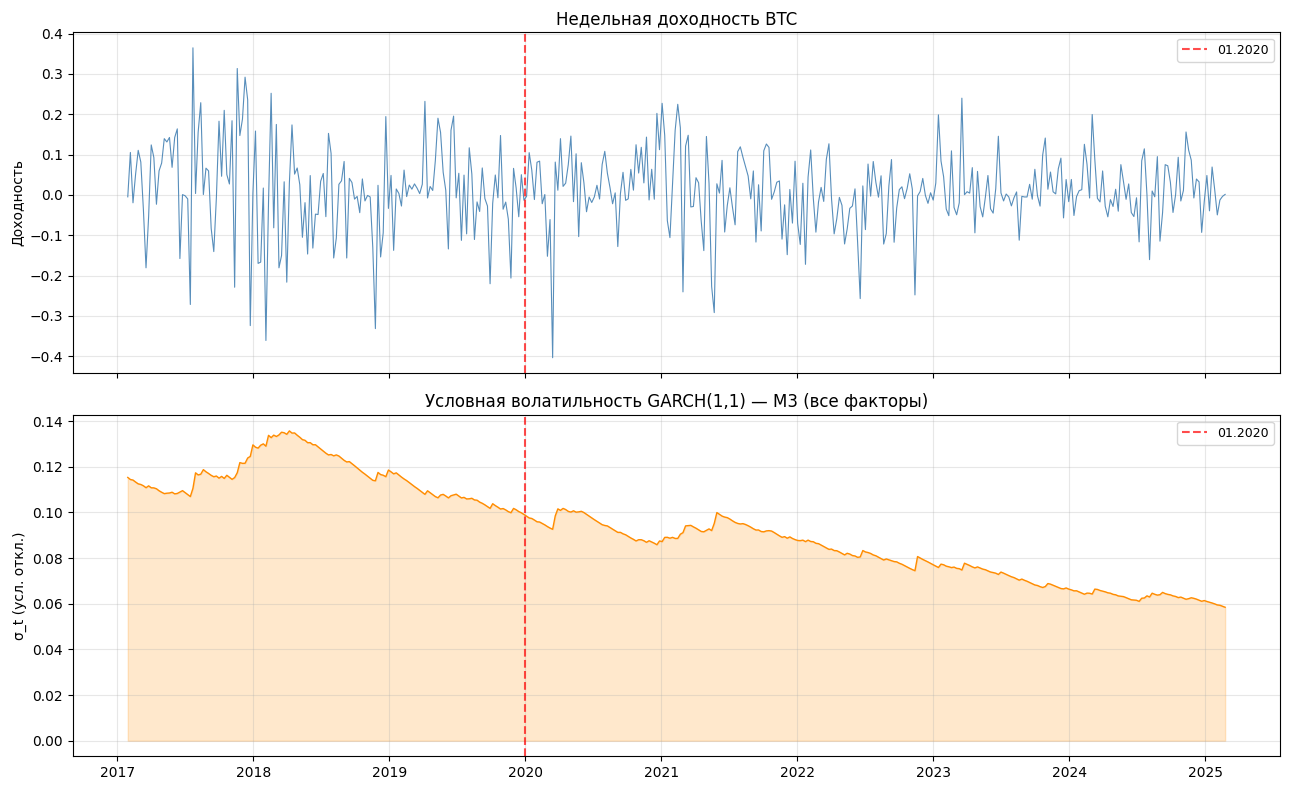

График сохранён: data/processed/garch_cond_vol.png


In [18]:
# Условная волатильность из М3 (все факторы, полный период)
cond_vol = g3.conditional_volatility / 100  # обратное масштабирование

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Доходность BTC
ax1.plot(df.index[-len(cond_vol):], df[Y_VAR].iloc[-len(cond_vol):],
         color='steelblue', linewidth=0.8, alpha=0.9)
ax1.axvline(pd.Timestamp('2020-01-01'), color='red', linestyle='--', alpha=0.7, label='01.2020')
ax1.set_title('Недельная доходность BTC')
ax1.set_ylabel('Доходность')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Условная волатильность
vol_index = df.index[-len(cond_vol):]
ax2.plot(vol_index, cond_vol.values, color='darkorange', linewidth=1.0)
ax2.axvline(pd.Timestamp('2020-01-01'), color='red', linestyle='--', alpha=0.7, label='01.2020')
ax2.fill_between(vol_index, cond_vol.values, alpha=0.2, color='darkorange')
ax2.set_title('Условная волатильность GARCH(1,1) — М3 (все факторы)')
ax2.set_ylabel('σ_t (усл. откл.)')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('../data/processed/garch_cond_vol.png', dpi=100, bbox_inches='tight')
plt.show()
print('График сохранён: data/processed/garch_cond_vol.png')

## 7. Сводная таблица GARCH-параметров дисперсии

In [19]:
garch_variance_summary = []

configs = [
    ('М1: Крипто', CRYPTO_VARS,   df,  'Полный'),
    ('М2: Внешние', EXTERNAL_VARS, df,  'Полный'),
    ('М3: Все',     ALL_VARS,      df,  'Полный'),
    ('М4: Расшир.', ALL_VARS_EXT,  df,  'Полный'),
    ('М1: Крипто', CRYPTO_VARS,   p1,  '2017–2019'),
    ('М2: Внешние', EXTERNAL_VARS, p1,  '2017–2019'),
    ('М1: Крипто', CRYPTO_VARS,   p2,  '2020–2025'),
    ('М2: Внешние', EXTERNAL_VARS, p2,  '2020–2025'),
]

for model_label, x_vars, data, period in configs:
    r = run_garch(data, Y_VAR, x_vars)
    p = r.params
    pv = r.pvalues
    alpha = float(p.get('alpha[1]', np.nan))
    beta  = float(p.get('beta[1]',  np.nan))
    pa    = float(pv.get('alpha[1]', np.nan))
    pb    = float(pv.get('beta[1]',  np.nan))
    sa    = '***' if pa<0.01 else ('**' if pa<0.05 else ('*' if pa<0.1 else ''))
    sb    = '***' if pb<0.01 else ('**' if pb<0.05 else ('*' if pb<0.1 else ''))
    garch_variance_summary.append({
        'Модель': model_label,
        'Период': period,
        'α (ARCH)': f'{alpha:.4f}{sa}',
        'β (GARCH)': f'{beta:.4f}{sb}',
        'α + β': round(alpha + beta, 4),
        'AIC': round(r.aic, 2),
    })

var_summary_df = pd.DataFrame(garch_variance_summary)
print('=== Параметры уравнения дисперсии GARCH(1,1) ===')
display(var_summary_df)
print('\nα + β близко к 1 → высокая персистентность волатильности (типично для крипто)')

=== Параметры уравнения дисперсии GARCH(1,1) ===


,Модель,Период,α (ARCH),β (GARCH),α + β,AIC
0,М1: Крипто,Полный,0.0137,0.9830***,0.9967,3113.92
1,М2: Внешние,Полный,0.0114,0.9853***,0.9966,3095.64
2,М3: Все,Полный,0.0123,0.9842***,0.9965,3096.95
3,М4: Расшир.,Полный,0.0129,0.9836***,0.9965,3101.29
4,М1: Крипто,2017–2019,0.1296,0.7232***,0.8528,1207.12
5,М2: Внешние,2017–2019,0.1256,0.7322***,0.8578,1204.66
6,М1: Крипто,2020–2025,0.0000,0.9959***,0.9959,1904.28
7,М2: Внешние,2020–2025,0.2209*,0.1566,0.3775,1892.18



α + β близко к 1 → высокая персистентность волатильности (типично для крипто)


## 8. Выводы: устойчивость результатов

In [20]:
print('=== ВЫВОДЫ ПО УСТОЙЧИВОСТИ РЕЗУЛЬТАТОВ ===')
print()

# Сравниваем значимость S&P 500 в OLS и GARCH по подпериодам
for period_name, data in [('2017–2019', p1), ('2020–2025', p2)]:
    g = run_garch(data, Y_VAR, EXTERNAL_VARS)
    sp500_p = float(g.pvalues.get('r_sp500', 1.0))
    sp500_c = float(g.params.get('r_sp500', 0)) / 100
    stars   = '***' if sp500_p<0.01 else ('**' if sp500_p<0.05 else ('*' if sp500_p<0.1 else 'незначим'))
    print(f'S&P 500 в GARCH М2 ({period_name}): коэф.={sp500_c:.4f}, p={sp500_p:.4f} {stars}')

print()
for period_name, data in [('2017–2019', p1), ('2020–2025', p2)]:
    g = run_garch(data, Y_VAR, CRYPTO_VARS)
    lag_p = float(g.pvalues.get('r_btc_lag', 1.0))
    lag_c = float(g.params.get('r_btc_lag', 0)) / 100
    stars  = '***' if lag_p<0.01 else ('**' if lag_p<0.05 else ('*' if lag_p<0.1 else 'незначим'))
    print(f'BTC momentum в GARCH М1 ({period_name}): коэф.={lag_c:.4f}, p={lag_p:.4f} {stars}')

print()
print('Интерпретация:')
print('  • Если S&P 500 значим в P2 в GARCH — результаты OLS устойчивы (H2 подтверждается)')
print('  • Если ARCH-параметры значимы — GARCH модель обоснована')
print('  • α + β < 1 — ковариационная стационарность соблюдена')

=== ВЫВОДЫ ПО УСТОЙЧИВОСТИ РЕЗУЛЬТАТОВ ===

S&P 500 в GARCH М2 (2017–2019): коэф.=0.2471, p=0.6872 незначим
S&P 500 в GARCH М2 (2020–2025): коэф.=1.0963, p=0.0000 ***

BTC momentum в GARCH М1 (2017–2019): коэф.=0.0239, p=0.7710 незначим
BTC momentum в GARCH М1 (2020–2025): коэф.=0.1141, p=0.0844 *

Интерпретация:
  • Если S&P 500 значим в P2 в GARCH — результаты OLS устойчивы (H2 подтверждается)
  • Если ARCH-параметры значимы — GARCH модель обоснована
  • α + β < 1 — ковариационная стационарность соблюдена
